In [1]:
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

In [2]:
#directory
fpath = 'C:\\Users\\gg00642\\OneDrive - University of Surrey\\Desktop\\Actigraphy Sara'

In [3]:
df = pd.read_excel(fpath + '\\1.1_database_variables.xlsx')

In [4]:
df['month'] = df['date'].dt.month

In [5]:
df['year'] = df['date'].dt.year

In [6]:
#filter the data and create different dataframe for the year 2022, 2023 and 2024 only
df_2022 = df[df['date'].dt.year == 2022]
df_2023 = df[df['date'].dt.year == 2023]
df_2024 = df[df['date'].dt.year == 2024]

In [7]:
# Function to convert hours to hh:mm format
def hours_to_hhmm(x, pos):
    hours = int(x)
    minutes = int((x - hours) * 60)
    return f'{hours:02d}:{minutes:02d}'

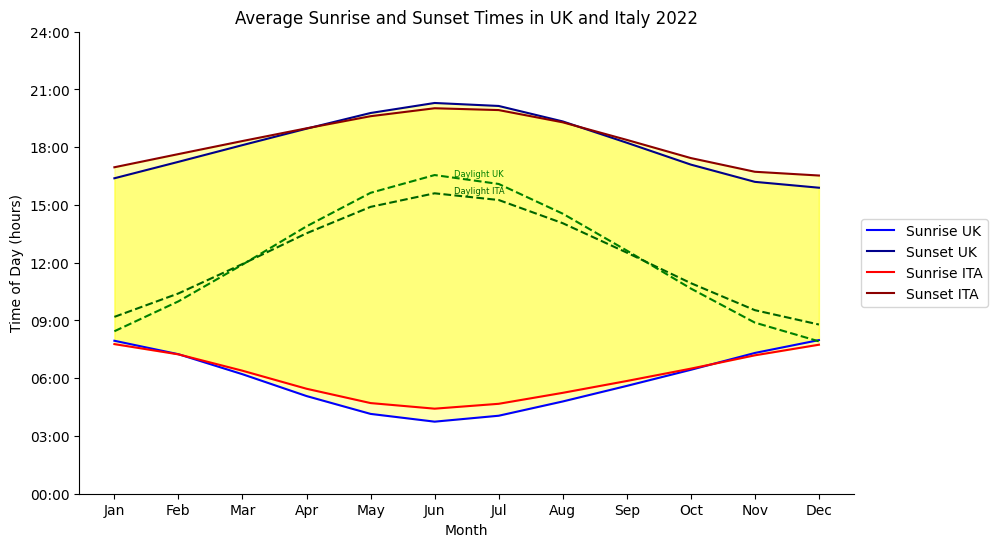

In [8]:
# Grouping by month and averaging sunrise and sunset times for both UK and ITA
monthly_avg = df_2022.groupby('month').agg({
    'sunrise (uk), hours': 'mean',
    'sunset (uk), hours': 'mean',
    'sunrise (ita), hours': 'mean',
    'sunset (ita), hours': 'mean'
}).reset_index()

# Re-attempting the plot with averaged data
plt.figure(figsize=(10, 6))

# Remove spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# UK sunrise and sunset
plt.plot(monthly_avg['month'], monthly_avg['sunrise (uk), hours'], label='Sunrise UK', color='blue')
plt.plot(monthly_avg['month'], monthly_avg['sunset (uk), hours'], label='Sunset UK', color='darkblue')

# ITA sunrise and sunset
plt.plot(monthly_avg['month'], monthly_avg['sunrise (ita), hours'], label='Sunrise ITA', color='red')
plt.plot(monthly_avg['month'], monthly_avg['sunset (ita), hours'], label='Sunset ITA', color='darkred')

# Daylight length 
plt.plot(monthly_avg['month'], monthly_avg['sunset (uk), hours'] - monthly_avg['sunrise (uk), hours'], label='Daylength UK', color='green', linestyle='--',)
plt.plot(monthly_avg['month'], monthly_avg['sunset (ita), hours'] - monthly_avg['sunrise (ita), hours'], label='Daylength ITA', color='darkgreen', linestyle='--')

# Annotation daylight on daylight length
plt.text(6.3, 16.5, 'Daylight UK', color='green', fontsize=6)
plt.text(6.3, 15.6, 'Daylight ITA', color='darkgreen', fontsize=6)

# Filling the area between sunrise and sunset
plt.fill_between(monthly_avg['month'], monthly_avg['sunrise (uk), hours'], monthly_avg['sunset (uk), hours'], color='yellow', alpha=0.3)
plt.fill_between(monthly_avg['month'], monthly_avg['sunrise (ita), hours'], monthly_avg['sunset (ita), hours'], color='yellow', alpha=0.3)

# Month names to the x-axis
plt.xticks(monthly_avg['month'], ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# Labels and title
plt.xlabel('Month')
plt.ylabel('Time of Day (hours)')
plt.title('Average Sunrise and Sunset Times in UK and Italy 2022')

# Format y-axis to hh:mm
plt.gca().yaxis.set_major_formatter(FuncFormatter(hours_to_hhmm))

# y axis to have 24 hours and 3 hours interval
plt.yticks(range(0, 25, 3))

# Legend
handles, labels = plt.gca().get_legend_handles_labels()
filtered_handles = [h for h, l in zip(handles, labels) if 'Daylength' not in l]
filtered_labels = [l for l in labels if 'Daylength' not in l]
plt.legend(filtered_handles, filtered_labels, loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()


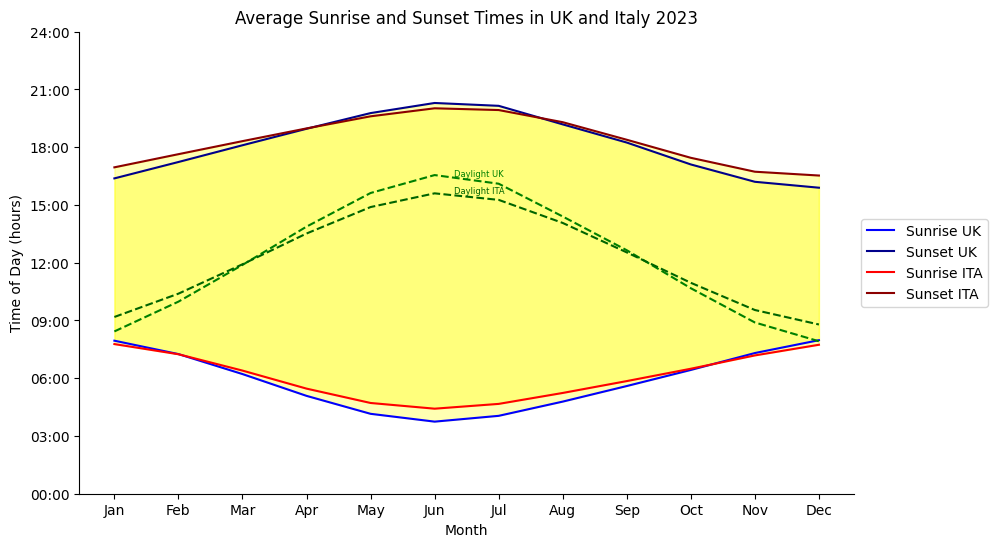

In [9]:
# Grouping by month and averaging sunrise and sunset times for both UK and ITA
monthly_avg = df_2023.groupby('month').agg({
    'sunrise (uk), hours': 'mean',
    'sunset (uk), hours': 'mean',
    'sunrise (ita), hours': 'mean',
    'sunset (ita), hours': 'mean'
}).reset_index()

# Re-attempting the plot with averaged data
plt.figure(figsize=(10, 6))

# Remove spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# UK sunrise and sunset
plt.plot(monthly_avg['month'], monthly_avg['sunrise (uk), hours'], label='Sunrise UK', color='blue')
plt.plot(monthly_avg['month'], monthly_avg['sunset (uk), hours'], label='Sunset UK', color='darkblue')

# ITA sunrise and sunset
plt.plot(monthly_avg['month'], monthly_avg['sunrise (ita), hours'], label='Sunrise ITA', color='red')
plt.plot(monthly_avg['month'], monthly_avg['sunset (ita), hours'], label='Sunset ITA', color='darkred')

# Daylight length 
plt.plot(monthly_avg['month'], monthly_avg['sunset (uk), hours'] - monthly_avg['sunrise (uk), hours'], label='Daylength UK', color='green', linestyle='--',)
plt.plot(monthly_avg['month'], monthly_avg['sunset (ita), hours'] - monthly_avg['sunrise (ita), hours'], label='Daylength ITA', color='darkgreen', linestyle='--')

# Annotation on daylight length
plt.text(6.3, 16.5, 'Daylight UK', color='green', fontsize=6)
plt.text(6.3, 15.6, 'Daylight ITA', color='darkgreen', fontsize=6)

plt.fill_between(monthly_avg['month'], monthly_avg['sunrise (uk), hours'], monthly_avg['sunset (uk), hours'], color='yellow', alpha=0.3)
plt.fill_between(monthly_avg['month'], monthly_avg['sunrise (ita), hours'], monthly_avg['sunset (ita), hours'], color='yellow', alpha=0.3)

plt.xticks(monthly_avg['month'], ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# Adding labels and title
plt.xlabel('Month')
plt.ylabel('Time of Day (hours)')
plt.title('Average Sunrise and Sunset Times in UK and Italy 2023')

# Format y-axis to hh:mm
plt.gca().yaxis.set_major_formatter(FuncFormatter(hours_to_hhmm))

# Change y axis to have 24 hours and 3 hours interval
plt.yticks(range(0, 25, 3))

# Adding legend to the right of the plot, excluding daylight length
handles, labels = plt.gca().get_legend_handles_labels()
filtered_handles = [h for h, l in zip(handles, labels) if 'Daylength' not in l]
filtered_labels = [l for l in labels if 'Daylength' not in l]
plt.legend(filtered_handles, filtered_labels, loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

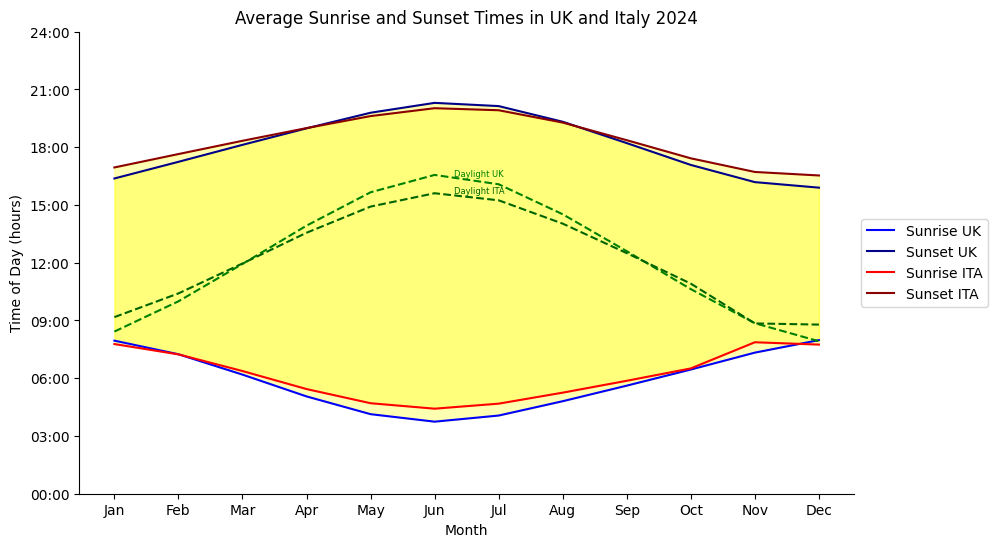

In [10]:
# Grouping by month and averaging sunrise and sunset times for both UK and ITA
monthly_avg = df_2024.groupby('month').agg({
    'sunrise (uk), hours': 'mean',
    'sunset (uk), hours': 'mean',
    'sunrise (ita), hours': 'mean',
    'sunset (ita), hours': 'mean'
}).reset_index()

# Re-attempting the plot with averaged data
plt.figure(figsize=(10, 6))

# Remove spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# UK sunrise and sunset
plt.plot(monthly_avg['month'], monthly_avg['sunrise (uk), hours'], label='Sunrise UK', color='blue')
plt.plot(monthly_avg['month'], monthly_avg['sunset (uk), hours'], label='Sunset UK', color='darkblue')

# ITA sunrise and sunset
plt.plot(monthly_avg['month'], monthly_avg['sunrise (ita), hours'], label='Sunrise ITA', color='red')
plt.plot(monthly_avg['month'], monthly_avg['sunset (ita), hours'], label='Sunset ITA', color='darkred')

# Daylight length 
plt.plot(monthly_avg['month'], monthly_avg['sunset (uk), hours'] - monthly_avg['sunrise (uk), hours'], label='Daylength UK', color='green', linestyle='--',)
plt.plot(monthly_avg['month'], monthly_avg['sunset (ita), hours'] - monthly_avg['sunrise (ita), hours'], label='Daylength ITA', color='darkgreen', linestyle='--')

# Add annotation daylight on daylight length lines
plt.text(6.3, 16.5, 'Daylight UK', color='green', fontsize=6)
plt.text(6.3, 15.6, 'Daylight ITA', color='darkgreen', fontsize=6)

# Colour the space between sunrise and sunset for both locations
plt.fill_between(monthly_avg['month'], monthly_avg['sunrise (uk), hours'], monthly_avg['sunset (uk), hours'], color='yellow', alpha=0.3)
plt.fill_between(monthly_avg['month'], monthly_avg['sunrise (ita), hours'], monthly_avg['sunset (ita), hours'], color='yellow', alpha=0.3)

# Add month names to the x-axis
plt.xticks(monthly_avg['month'], ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# Adding labels and title
plt.xlabel('Month')
plt.ylabel('Time of Day (hours)')
plt.title('Average Sunrise and Sunset Times in UK and Italy 2024')

# Format y-axis to hh:mm
plt.gca().yaxis.set_major_formatter(FuncFormatter(hours_to_hhmm))

# Y axis to have 24 hours and 3 hours interval
plt.yticks(range(0, 25, 3))

# Legend
handles, labels = plt.gca().get_legend_handles_labels()
filtered_handles = [h for h, l in zip(handles, labels) if 'Daylength' not in l]
filtered_labels = [l for l in labels if 'Daylength' not in l]
plt.legend(filtered_handles, filtered_labels, loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

In [11]:
# Grouping by both year and month to calculate average sunrise and sunset times for each year and month
df['year'] = df['date'].dt.year

# Group by both year and month
yearly_monthly_avg = df.groupby(['year', 'month']).agg({
    'sunrise (uk), hours': 'mean',
    'sunset (uk), hours': 'mean',
    'sunrise (ita), hours': 'mean',
    'sunset (ita), hours': 'mean'
}).reset_index()

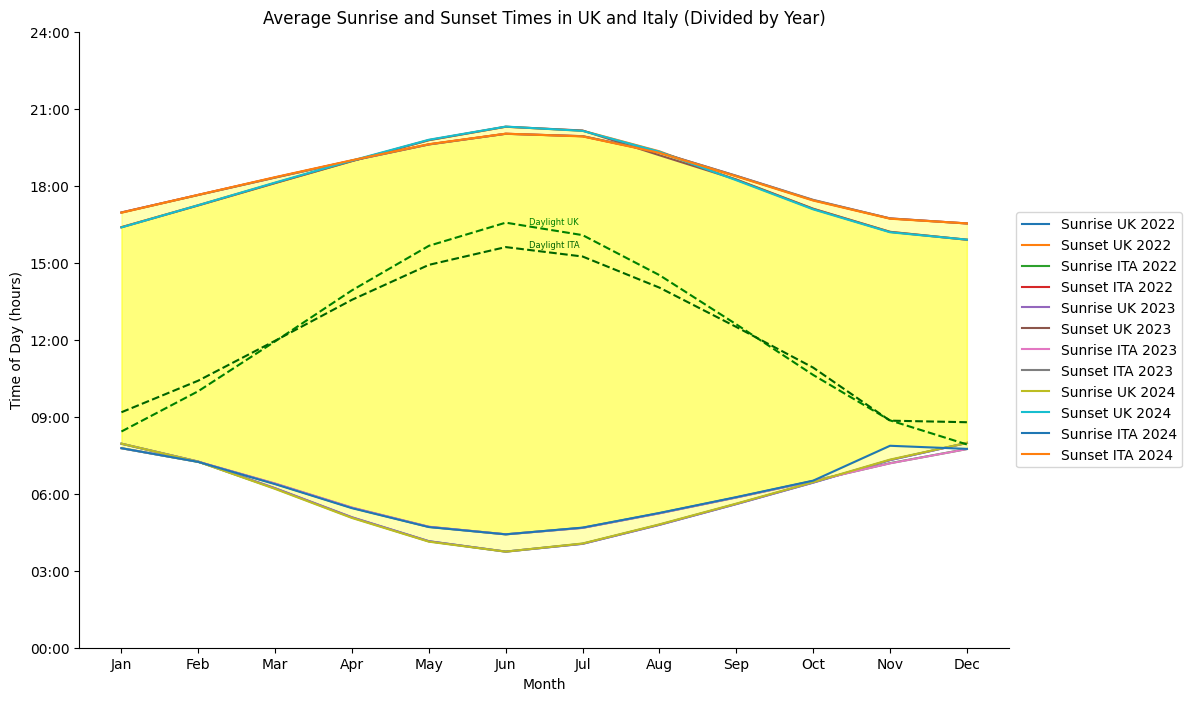

In [16]:
# Plotting the sunrise and sunset times divided by year
plt.figure(figsize=(12, 8))

# Plotting for each year separately
for year in yearly_monthly_avg['year'].unique():
    subset = yearly_monthly_avg[yearly_monthly_avg['year'] == year]
    
    # UK sunrise and sunset
    plt.plot(subset['month'], subset['sunrise (uk), hours'], label=f'Sunrise UK {year}', linestyle='-')
    plt.plot(subset['month'], subset['sunset (uk), hours'], label=f'Sunset UK {year}', linestyle='-')

    # ITA sunrise and sunset
    plt.plot(subset['month'], subset['sunrise (ita), hours'], label=f'Sunrise ITA {year}', linestyle='-')
    plt.plot(subset['month'], subset['sunset (ita), hours'], label=f'Sunset ITA {year}', linestyle='-')

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.fill_between(subset['month'], subset['sunrise (uk), hours'], subset['sunset (uk), hours'], color='yellow', alpha=0.3)
plt.fill_between(subset['month'], subset['sunrise (ita), hours'], subset['sunset (ita), hours'], color='yellow', alpha=0.3)

# Add month names to the x-axis
plt.xticks(monthly_avg['month'], ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# Daylight length 
plt.plot(monthly_avg['month'], monthly_avg['sunset (uk), hours'] - monthly_avg['sunrise (uk), hours'], label='Daylength UK', color='green', linestyle='--',)
plt.plot(monthly_avg['month'], monthly_avg['sunset (ita), hours'] - monthly_avg['sunrise (ita), hours'], label='Daylength ITA', color='darkgreen', linestyle='--')

# Add annotation daylight on daylight length lines
plt.text(6.3, 16.5, 'Daylight UK', color='green', fontsize=6)
plt.text(6.3, 15.6, 'Daylight ITA', color='darkgreen', fontsize=6)

# Format y-axis to hh:mm
plt.gca().yaxis.set_major_formatter(FuncFormatter(hours_to_hhmm))

# Y axis to have 24 hours and 3 hours interval
plt.yticks(range(0, 25, 3))

# Adding labels and title
plt.xlabel('Month')
plt.ylabel('Time of Day (hours)')
plt.title('Average Sunrise and Sunset Times in UK and Italy (Divided by Year)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Legend
handles, labels = plt.gca().get_legend_handles_labels()
filtered_handles = [h for h, l in zip(handles, labels) if 'Daylength' not in l]
filtered_labels = [l for l in labels if 'Daylength' not in l]
plt.legend(filtered_handles, filtered_labels, loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()
